In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
train_path = '/content/drive/MyDrive/AI Worksheet/FruitinAmazon/train'
test_path = '/content/drive/MyDrive/AI Worksheet/FruitinAmazon/test'

In [8]:
from PIL import Image
import os

train_dir = train_path
classes = os.listdir(train_dir)

corrupted = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print("Removed corrupted image:", img_path)

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


In [9]:
from PIL import Image
import os

corrupted = []

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print("Removed corrupted image:", img_path)

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


In [10]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset="training",
    seed=123
)

train_ds = train_ds.map(lambda x,y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

val_ds = val_ds.map(lambda x,y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [11]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([

layers.Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(128,128,3)),
layers.MaxPooling2D((2,2)),

layers.Conv2D(32,(3,3),padding='same',activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Flatten(),

layers.Dense(128,activation='relu'),
layers.Dense(64,activation='relu'),

layers.Dense(num_classes,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
"best_model.h5",
monitor='val_accuracy',
save_best_only=True,
mode='max'
)

early_stop = EarlyStopping(
monitor='val_loss',
patience=10
)

history = model.fit(
train_ds,
validation_data=val_ds,
epochs=250,
batch_size=16,
callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.1453 - loss: 1.9220

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 612ms/step - accuracy: 0.1389 - loss: 1.9555 - val_accuracy: 0.0556 - val_loss: 2.3834
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.1209 - loss: 1.9398

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 537ms/step - accuracy: 0.0972 - loss: 1.9396 - val_accuracy: 0.2222 - val_loss: 1.8493
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 533ms/step - accuracy: 0.3889 - loss: 1.6137 - val_accuracy: 0.1111 - val_loss: 1.8304
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 734ms/step - accuracy: 0.3472 - loss: 1.5591 - val_accuracy: 0.1667 - val_loss: 1.7769
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - accuracy: 0.5394 - loss: 1.3909

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 916ms/step - accuracy: 0.5556 - loss: 1.3774 - val_accuracy: 0.2778 - val_loss: 1.5804
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 0.5556 - loss: 1.1682 - val_accuracy: 0.2222 - val_loss: 1.6256
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 0.6528 - loss: 0.9089 - val_accuracy: 0.2778 - val_loss: 1.5966
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 0.8611 - loss: 0.7152 - val_accuracy: 0.2778 - val_loss: 1.6640
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.9028 - loss: 0.4972 - val_accuracy: 0.2222 - val_loss: 1.9064
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9103 - loss: 0.3957

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.9028 - loss: 0.4059 - val_accuracy: 0.3889 - val_loss: 1.6754
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 715ms/step - accuracy: 0.9583 - loss: 0.2942 - val_accuracy: 0.3889 - val_loss: 1.8595
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 752ms/step - accuracy: 0.9861 - loss: 0.1650 - val_accuracy: 0.3333 - val_loss: 2.3457
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step - accuracy: 0.9861 - loss: 0.1011 - val_accuracy: 0.3333 - val_loss: 1.9234
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 1.0000 - loss: 0.0473

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 1.0000 - loss: 0.0497 - val_accuracy: 0.4444 - val_loss: 1.8384
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 467ms/step - accuracy: 1.0000 - loss: 0.0427 - val_accuracy: 0.3889 - val_loss: 2.0343


In [14]:
test_loss, test_acc = model.evaluate(val_ds)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.3889 - loss: 2.0343
Test Accuracy: 0.3888888955116272
Test Loss: 2.0342721939086914


In [15]:
model.save("fruit_model.h5")

In [16]:
from tensorflow.keras.models import load_model

model = load_model("fruit_model.h5")

model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - accuracy: 0.3889 - loss: 2.0343


[2.0342721939086914, 0.3888888955116272]

In [17]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images)
    predicted = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted)

print(classification_report(y_true,y_pred,target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
              precision    recall  f1-score   support

     cupuacu       0.33      1.00      0.50         1
        acai       0.33      0.50      0.40         2
    graviola       1.00      0.67      0.80         3
     guarana       0.50      0.40      0.44         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.25      0.33      0.29         3

    accuracy                           0.39        18
   macro avg       0.40      0.48      0.41        18
weighted avg       0.40      0.39      0.38        18



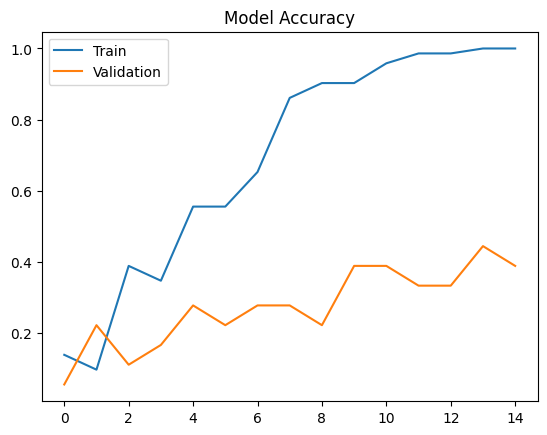

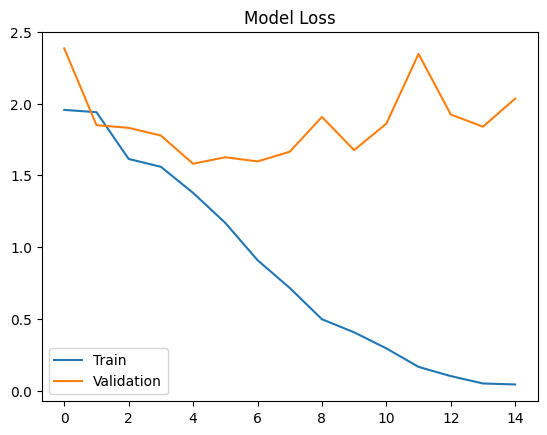

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train','Validation'])
plt.show()

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,224 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [21]:
model.predict(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step


array([[1.99491205e-06, 2.73910264e-05, 4.84135561e-03, 3.80139172e-05,
        1.27548759e-04, 9.94963646e-01],
       [2.75650245e-06, 1.35002506e-03, 7.53714485e-05, 1.69275061e-03,
        1.01868901e-02, 9.86692131e-01],
       [1.05624531e-05, 1.29588204e-03, 7.42172233e-07, 9.09140468e-01,
        8.87528211e-02, 7.99592352e-04],
       [5.16025489e-03, 8.73297572e-01, 4.15973458e-03, 1.07239641e-01,
        1.86170160e-03, 8.28096271e-03],
       [1.20672642e-03, 2.37730801e-01, 1.44310547e-02, 2.31631726e-01,
        2.67882168e-01, 2.47117504e-01],
       [2.45678741e-02, 1.12500794e-01, 2.45006802e-03, 8.57686460e-01,
        2.36453605e-03, 4.30339365e-04],
       [2.59115337e-03, 1.06537491e-01, 8.87579679e-01, 1.39140105e-03,
        4.41030279e-05, 1.85613858e-03],
       [2.05210671e-02, 1.04632184e-01, 5.42242825e-02, 2.71151364e-01,
        4.78647836e-02, 5.01606226e-01],
       [8.75518143e-01, 7.53993243e-02, 3.02654365e-03, 4.59102169e-02,
        7.96572494e-05, 